In [5]:
from abc import ABC, abstractmethod

# normalize

class Normalizer(ABC):
    @abstractmethod
    def fit(self, X): ...

    @abstractmethod
    def transform(self, X): ...

    @abstractmethod
    def inverse(self, X): ...

    def fit_transform(self, X):
        return self.fit(X).transform(X)


class MinMaxNormalizer(Normalizer):
    def fit(self, X):
        self.min = X.min(axis=0)
        self.max = X.max(axis=0)
        return self

    def transform(self, x):
        return (x - self.min) / (self.max - self.min)

    def inverse(self, x):
        return x * (self.max - self.min) + self.min



class ZScoreNormalizer(Normalizer):
    def fit(self, x):
        self.mean = x.mean(axis=0)
        self.std = x.std(axis=0)
        return self

    def transform(self, x):
        return (x - self.mean) / self.std

    def inverse(self, x):
        return x * self.std + self.mean

In [6]:
import numpy as np

class Metric(ABC):
    @abstractmethod
    def compute(self, y_true, y_pred) -> float: ...

    @abstractmethod
    def name(self) -> str: ...

class R2(Metric):
    def name(self): return "R2"

    def compute(self, y_true, y_pred):
        ss_res = ((y_true - y_pred) ** 2).sum()
        ss_tot = ((y_true - y_true.mean()) ** 2).sum()
        return 1 - ss_res / ss_tot


class MAPE(Metric):
    def name(self): return "MAPE"

    def compute(self, y_true, y_pred):
        mask = y_true != 0
        return (np.abs((y_true[mask] - y_pred[mask]) / y_true[mask])).mean() * 100


class MaxError(Metric):
    def name(self): return "MaxErr"

    def compute(self, y_true, y_pred):
        return np.abs(y_true - y_pred).max()


class LossFunction(Metric):
    @abstractmethod
    def grad(self, x, y, y_pred): ...

    def compute(self, y_true, y_pred):
        return self.loss(y_true, y_pred)

    @abstractmethod
    def loss(self, y, y_pred) -> float: ...

class MSELoss(LossFunction):
    def name(self): return "MSE"

    def loss(self, y, y_pred):
        return ((y_pred - y) ** 2).mean()

    def grad(self, x, y, y_pred):
        n = len(y)
        error = y_pred - y
        return (2 / n) * x.T @ error, (2 / n) * error.sum()


class MAELoss(LossFunction):
    def name(self): return "MAE"

    def loss(self, y, y_pred):
        return np.abs(y_pred - y).mean()

    def grad(self, X, y, y_pred):
        n = len(y)
        signs = np.sign(y_pred - y)
        return (1 / n) * X.T @ signs, (1 / n) * signs.sum()


class RMSELoss(LossFunction):
    def __init__(self):
        self._mse = MSELoss()

    def name(self): return "RMSE"

    def loss(self, y, y_pred):
        return self._mse.loss(y, y_pred) ** 0.5

    def grad(self, x, y, y_pred):
        mse_val = self._mse.loss(y, y_pred)
        w_grad, b_grad = self._mse.grad(x, y, y_pred)
        scale = 1 / (2 * mse_val ** 0.5 + 1e-12)
        return scale * w_grad, scale * b_grad

In [10]:
class R2(Metric):
    def name(self): return "R2"

    def compute(self, y_true, y_pred):
        ss_res = ((y_true - y_pred) ** 2).sum()
        ss_tot = ((y_true - y_true.mean()) ** 2).sum()
        return 1 - ss_res / ss_tot


class MAPE(Metric):
    def name(self): return "MAPE"

    def compute(self, y_true, y_pred):
        mask = y_true != 0
        return (np.abs((y_true[mask] - y_pred[mask]) / y_true[mask])).mean() * 100


class MaxError(Metric):
    def name(self): return "MaxErr"

    def compute(self, y_true, y_pred):
        return np.abs(y_true - y_pred).max()

In [8]:
class Evaluator:
    def __init__(self, metrics: list[Metric]):
        self.metrics = metrics

    def evaluate(self, y_true, y_pred) -> dict:
        return {m.name(): m.compute(y_true, y_pred) for m in self.metrics}

    def header(self) -> str:
        names = [m.name() for m in self.metrics]
        return "  ".join(f"{n:>10}" for n in names)

    def row(self, scores: dict) -> str:
        return "  ".join(f"{scores[m.name()]:>10.4f}" for m in self.metrics)

In [20]:
def remove_outliers_iqr(df, cols, k=1.5):
    mask = np.ones(len(df), dtype=bool)
    for col in cols:
        q1, q3 = df[col].quantile([0.25, 0.75])
        iqr = q3 - q1
        mask &= (df[col].values >= q1 - k * iqr) & (df[col].values <= q3 + k * iqr)
    return df[mask].reset_index(drop=True)

def linear(x, weights, bias):
    return x @ weights + bias

rng = np.random.default_rng(seed=42)

def train_model(x, y, loss_fn, lr, snapshot_every=500, tol=1e-7, patience=20, max_epochs=50000):
    n, d = x.shape
    weights = rng.uniform(size=d)
    bias = rng.uniform()
    prev_loss = float("inf")
    no_improve = 0
    history = []

    for epoch in range(max_epochs):
        y_pred = linear(x, weights, bias)
        l = loss_fn.loss(y, y_pred)
        w_grad, b_grad = loss_fn.grad(x, y, y_pred)
        weights -= lr * w_grad
        bias -= lr * b_grad

        history.append(l)

        if epoch % snapshot_every == 0:
            print(f"  Epoch {epoch:>6} | Loss: {l:.6f}")

        if abs(prev_loss - l) < tol:
            no_improve += 1
            if no_improve >= patience:
                print(f"  Converged at epoch {epoch} | Loss: {l:.6f}")
                break
        else:
            no_improve = 0
        prev_loss = l

    return weights, bias, history

In [32]:
import pandas as pd
from sklearn.model_selection import train_test_split

column_names = [
    'CRIM', 'ZN', 'INDUS', 'CHAS', 'NOX', 'RM', 'AGE',
    'DIS', 'RAD', 'TAX', 'PTRATIO', 'B', 'LSTAT', 'MEDV',
]

data = pd.read_csv("../shared_data/housing.csv", names=column_names, delimiter=r"\s+")
train, test = train_test_split(data, test_size=0.2, random_state=42)

print(f"Train: {len(train)}, Test: {len(test)}")

FEATURES = ['CRIM', 'ZN', 'INDUS', 'CHAS', 'NOX', 'RM', 'AGE',
            'DIS', 'RAD', 'TAX', 'PTRATIO', 'B', 'LSTAT']
TARGET = 'MEDV'

CONTINUOUS_FEATURES = [f for f in FEATURES if f != 'CHAS']
# train = remove_outliers_iqr(train, CONTINUOUS_FEATURES + [TARGET], k=3.0)
print(f"Train after outlier removal: {len(train)}")

raw_X_train = train[FEATURES].values
raw_y_train = train[TARGET].values
raw_X_test = test[FEATURES].values
raw_y_test = test[TARGET].values

variances = raw_X_train.std(axis=0)
valid_mask = variances > 0

if not valid_mask.all():
    dropped = [f for f, v in zip(FEATURES, valid_mask) if not v]
    print(f"Dropping zero-variance features: {dropped}")
    FEATURES = [f for f, v in zip(FEATURES, valid_mask) if v]
    raw_X_train = raw_X_train[:, valid_mask]
    raw_X_test = raw_X_test[:, valid_mask]

norm_configs = [
    ("MinMax",  MinMaxNormalizer(), MinMaxNormalizer()),
    ("Z-score", ZScoreNormalizer(), ZScoreNormalizer()),
]

loss_fns: list[LossFunction] = [MSELoss(), MAELoss(), RMSELoss()]

evaluator = Evaluator([MSELoss(), MAELoss(), RMSELoss(), R2(), MAPE(), MaxError()])

lr = 0.01
results = []

for norm_label, x_norm, y_norm in norm_configs:
    X_tr = x_norm.fit_transform(raw_X_train)
    y_tr = y_norm.fit_transform(raw_y_train)
    X_te = x_norm.transform(raw_X_test)

    for loss_fn in loss_fns:
        print(f"\n=== {norm_label} + {loss_fn.name()} ===")
        weights, bias, history = train_model(X_tr, y_tr, loss_fn, lr)

        y_pred = y_norm.inverse(linear(X_te, weights, bias))
        scores = evaluator.evaluate(raw_y_test, y_pred)

        results.append({
            "norm": norm_label,
            "loss": loss_fn.name(),
            "scores": scores,
            "weights": weights,
            "bias": bias,
            "history": history,
        })

print(f"\n{'Norm':<10} {'Loss':<6} {evaluator.header()}")
print("-" * (18 + len(evaluator.header())))
for r in results:
    print(f"{r['norm']:<10} {r['loss']:<6} {evaluator.row(r['scores'])}")

best = max(results, key=lambda r: r["scores"]["R2"])
print(f"\nBest model: {best['norm']} + {best['loss']} (R2 = {best['scores']['R2']:.4f})")
print("\nFeature weights (normalized scale):")
for feat, w in sorted(zip(FEATURES, best["weights"]), key=lambda x: abs(x[1]), reverse=True):
    print(f"  {feat:<10} {w:>+.4f}")

Train: 404, Test: 102
Train after outlier removal: 404

=== MinMax + MSE ===
  Epoch      0 | Loss: 8.918801
  Epoch    500 | Loss: 0.061214
  Epoch   1000 | Loss: 0.038911
  Epoch   1500 | Loss: 0.027706
  Epoch   2000 | Loss: 0.021672
  Epoch   2500 | Loss: 0.018274
  Epoch   3000 | Loss: 0.016276
  Epoch   3500 | Loss: 0.015046
  Epoch   4000 | Loss: 0.014247
  Epoch   4500 | Loss: 0.013698
  Epoch   5000 | Loss: 0.013298
  Epoch   5500 | Loss: 0.012992
  Epoch   6000 | Loss: 0.012747
  Epoch   6500 | Loss: 0.012542
  Epoch   7000 | Loss: 0.012368
  Epoch   7500 | Loss: 0.012215
  Epoch   8000 | Loss: 0.012080
  Epoch   8500 | Loss: 0.011960
  Epoch   9000 | Loss: 0.011851
  Epoch   9500 | Loss: 0.011753
  Epoch  10000 | Loss: 0.011664
  Epoch  10500 | Loss: 0.011583
  Epoch  11000 | Loss: 0.011509
  Epoch  11500 | Loss: 0.011441
  Epoch  12000 | Loss: 0.011379
  Epoch  12500 | Loss: 0.011322
  Converged at epoch 12987 | Loss: 0.011272

=== MinMax + MAE ===
  Epoch      0 | Loss: 2.

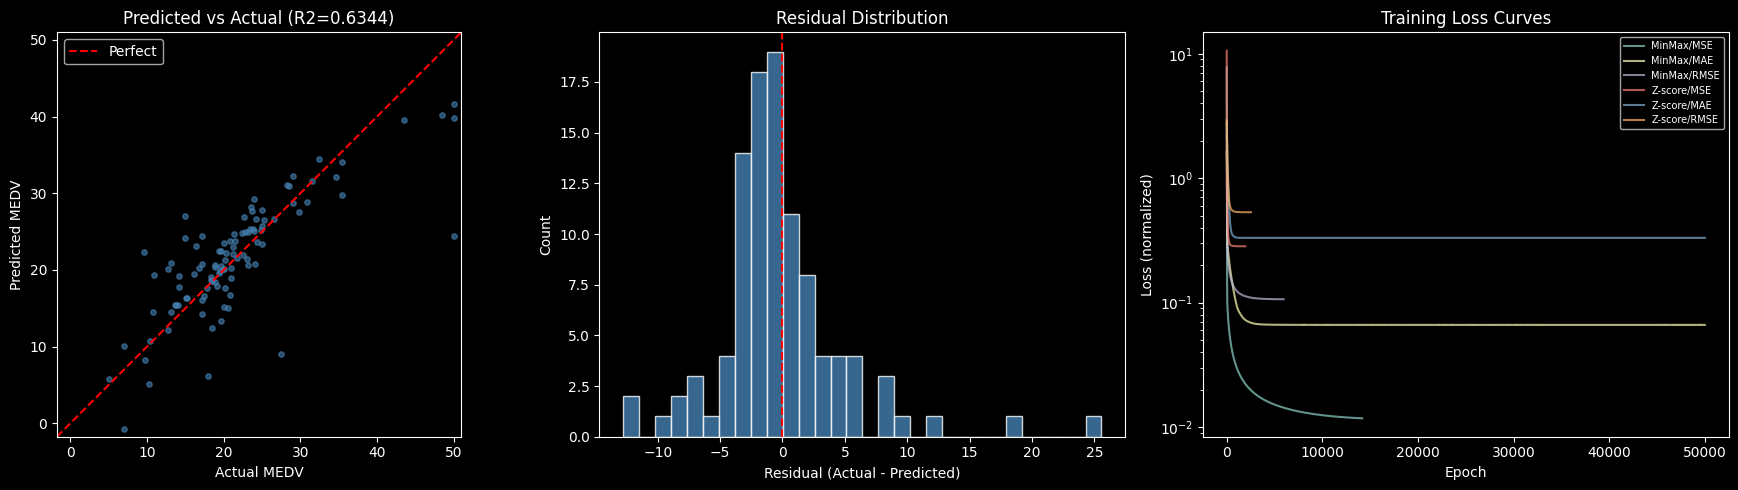

In [27]:
import matplotlib.pyplot as plt

fig, axes = plt.subplots(1, 3, figsize=(18, 5))

norm_cfg = [c for c in norm_configs if c[0] == best["norm"]][0]
y_pred_best = norm_cfg[2].inverse(
    linear(norm_cfg[1].transform(raw_X_test), best["weights"], best["bias"])
)

ax = axes[0]
ax.scatter(raw_y_test, y_pred_best, s=15, alpha=0.6, color="steelblue")
lims = [
    min(raw_y_test.min(), y_pred_best.min()) - 1,
    max(raw_y_test.max(), y_pred_best.max()) + 1,
]
ax.plot(lims, lims, color="red", linewidth=1.5, linestyle="--", label="Perfect")
ax.set_xlabel("Actual MEDV")
ax.set_ylabel("Predicted MEDV")
ax.set_title(f"Predicted vs Actual (R2={best['scores']['R2']:.4f})")
ax.legend()
ax.set_xlim(lims)
ax.set_ylim(lims)
ax.set_aspect("equal")

residuals = raw_y_test - y_pred_best
ax = axes[1]
ax.hist(residuals, bins=30, color="steelblue", edgecolor="white", alpha=0.8)
ax.axvline(0, color="red", linestyle="--", linewidth=1.5)
ax.set_xlabel("Residual (Actual - Predicted)")
ax.set_ylabel("Count")
ax.set_title("Residual Distribution")

ax = axes[2]
for r in results:
    ax.plot(r["history"], label=f"{r['norm']}/{r['loss']}", alpha=0.7)
ax.set_xlabel("Epoch")
ax.set_ylabel("Loss (normalized)")
ax.set_title("Training Loss Curves")
ax.legend(fontsize=7)
ax.set_yscale("log")

plt.tight_layout()
plt.savefig("multivariable_analysis.png", dpi=150, bbox_inches="tight")
plt.show()